# Lab 1 : Linear Regression

## G3 SDI - Machine Learning

In this lab, we are going to implement linear regression and ridge regression on a medical data example. The data come from a medical study (Stamey et al., 1989), whose goal was to predict the level of prostate-specific antigen (`lpsa`) from some clinical measurements. These clinical exams are carried out before a possible prostatectomy.

The measurements are log cancer volume `lcavol`, log prostate weight `lweight`, age of the patient `age`, log of benign prostatic hyperplasia amount `lbph`, seminal vesicle invasion `svi`, log of capsular penetration `lcp`, Gleason score `gleason`, and percent of Gleason scores 4 or 5 `pgg45`. The variable `svi` is binary, `gleason` is ordinal, others are quantitative.

### Instructions
* Rename your notebook with your surnames as `lab1_Name1_Name2.ipynb`, and include your names in the notebook.
* Your code, and its output, must be commented !
* Please upload your notebook on Moodle in the dedicated section before the deadline.

**Compte rendu — TP 1.** Auteur : Ugo Roccamatisi.


In [2]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

### Part 1 - Linear regression

In this first part, we focus on using linear regression.

**Q1.** Load the data from the `.npy` files included in the archive (use `np.load`). How many examples are there ? How many features ?

In [5]:
from pathlib import Path
# Chemins relatifs au notebook : le dossier peut être déplacé.
X = np.load(Path('data_X.npy'))
y = np.load(Path('data_y.npy'))
feature_names = ['lcavol','lweight','age','lbph','svi','lcp','gleason','pgg45']
print(f'Exemples : {X.shape[0]}, variables : {X.shape[1]}, cible : {y.shape}')

Exemples : 97, variables : 8, cible : (97,)


**Réponse.** Les dimensions affichées donnent 97 observations et 8 variables explicatives.

**Q2.** Check whether there are some missing entries in the dataset (both in X and y). Use `np.isnan`.

In [8]:
# np.isnan renvoie un masque ; la somme compte les valeurs manquantes.
print('Valeurs manquantes dans X :', np.isnan(X).sum())
print('Valeurs manquantes dans y :', np.isnan(y).sum())

Valeurs manquantes dans X : 0
Valeurs manquantes dans y : 0


**Réponse.** Le comptage indique si des données sont manquantes dans les prédicteurs ou la cible.

**Q3.** Divide the dataset into a training set (80%) and a test set (20%), using `train_test_split` with `random_state = 0` (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)).

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=0)
print('Train/test :', X_train.shape, X_test.shape)

Train/test : (77, 8) (20, 8)


**Q4.** Standardize the training set, and apply the same operation to the test set. Use `StandardScaler` (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)). Recall what standardization means.

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)  # Moyennes et écarts-types calculés sur train seulement.
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print('Moyennes train :',np.round(X_train_s.mean(axis=0),4))
print('Écarts-types train :',np.round(X_train_s.std(axis=0),4))

Moyennes train : [ 0. -0. -0. -0.  0.  0.  0.  0.]
Écarts-types train : [1. 1. 1. 1. 1. 1. 1. 1.]


**Réponse.** Standardiser signifie soustraire la moyenne de chaque colonne du train puis diviser par son écart-type ; les mêmes paramètres sont appliqués au test.

**Q5.** Compute the auto-covariance matrix from the training set, and display it (you might want to use `plt.imshow`). What can we learn from this ?

Corrélations hors diagonale les plus fortes :
gleason pgg45 0.789
svi lcp 0.712
lcavol lcp 0.692
lcp pgg45 0.605


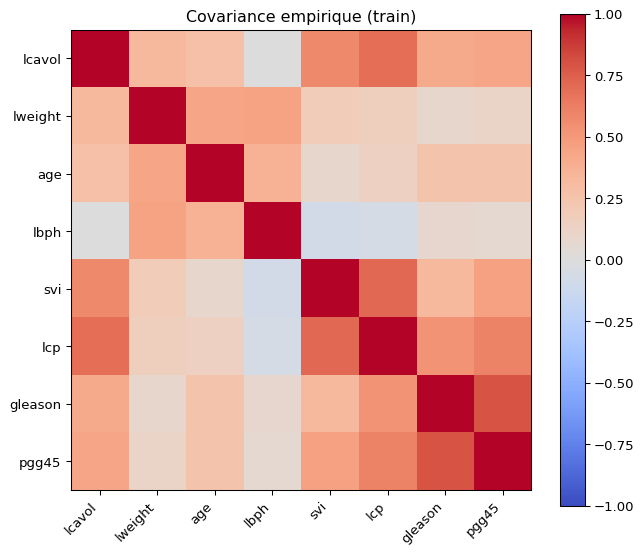

In [16]:
# Covariance empirique non biaisée des variables standardisées.
cov = np.cov(X_train_s,rowvar=False)
fig, ax = plt.subplots(figsize=(7,6))
im=ax.imshow(cov,cmap='coolwarm',vmin=-1,vmax=1)
ax.set(xticks=range(8),yticks=range(8),xticklabels=feature_names,yticklabels=feature_names,title='Covariance empirique (train)')
plt.setp(ax.get_xticklabels(),rotation=45,ha='right');fig.colorbar(im,ax=ax);fig.tight_layout();plt.show()
print('Corrélations hors diagonale les plus fortes :')
for i,j in sorted(((i,j) for i in range(8) for j in range(i+1,8)),key=lambda ij:abs(cov[ij]),reverse=True)[:4]:print(feature_names[i],feature_names[j],round(cov[i,j],3))

**Réponse.** La diagonale vaut environ 1 après standardisation ; les termes hors diagonale indiquent les dépendances linéaires et une éventuelle colinéarité. La liste imprimée précise les paires les plus corrélées.

**Q6.** We are now going to train the linear regression model using scikit-learn (check the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)). Use the `.fit` method on the training set. Retrieve the coefficients obtained by scikit-learn using the attributes `.intercept_` and `.coef_`, and check that it corresponds to the closed-form solution from the lecture (you might want to use `np.hstack` to concatenate X with a column of ones).

In [19]:
from sklearn.linear_model import LinearRegression
ols=LinearRegression().fit(X_train_s,y_train)
# La colonne de 1 encode l'ordonnée à l'origine ; lstsq est robuste numériquement.
A=np.column_stack((np.ones(len(X_train_s)),X_train_s))
beta=np.linalg.lstsq(A,y_train,rcond=None)[0]
print('Intercept et coefficients sklearn :',np.round(np.r_[ols.intercept_,ols.coef_],4))
print('Solution moindres carrés :',np.round(beta,4))
print('Égalité numérique :',np.allclose(beta,np.r_[ols.intercept_,ols.coef_]))

Intercept et coefficients sklearn : [ 2.5334  0.7649  0.2151 -0.1982  0.1701  0.3377 -0.2353  0.106   0.0612]
Solution moindres carrés : [ 2.5334  0.7649  0.2151 -0.1982  0.1701  0.3377 -0.2353  0.106   0.0612]
Égalité numérique : True


**Réponse.** Les coefficients et l’intercept coïncident numériquement avec la solution des moindres carrés sur la matrice augmentée.

**Q7.** Obtain the model predictions on the test set using the `.predict` method. Then compute the MSE and the MAE (you may want to use the functions below).

In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
pred_ols=ols.predict(X_test_s)
mse_ols=mean_squared_error(y_test,pred_ols);mae_ols=mean_absolute_error(y_test,pred_ols)
print(f'Régression linéaire — MSE {mse_ols:.4f} ; MAE {mae_ols:.4f}')

Régression linéaire — MSE 0.5402 ; MAE 0.5645


### Part 2 - Ridge regression

In this second part, we now turn to ridge regression.

**Q1.** Fit the ridge regression model (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)) with $\lambda = 1$, using the `.fit` method on the training set. Again, retrieve the coefficients, and check that they match with the closed-form solution from the lecture. How do they differ from the ones obtained with linear regression ?

In [25]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1).fit(X_train_s,y_train)
# sklearn ne pénalise pas l'intercept : centrer y et X avant de résoudre.
xc=X_train_s-X_train_s.mean(axis=0);yc=y_train-y_train.mean()
w=np.linalg.solve(xc.T@xc+np.eye(X.shape[1]),xc.T@yc)
b=ridge.intercept_  # moyenne(y) - moyenne(X) @ w
print('Coefficients ridge :',np.round(ridge.coef_,4))
print('Solution fermée :',np.round(w,4))
print('Égalité numérique :',np.allclose(w,ridge.coef_))
print('Normes L2 OLS/ridge :',round(np.linalg.norm(ols.coef_),4),round(np.linalg.norm(w),4))

Coefficients ridge : [ 0.7422  0.216  -0.1897  0.1655  0.3289 -0.2098  0.1028  0.0594]
Solution fermée : [ 0.7422  0.216  -0.1897  0.1655  0.3289 -0.2098  0.1028  0.0594]
Égalité numérique : True
Normes L2 OLS/ridge : 0.9401 0.9095


**Réponse.** La pénalisation L2 contracte globalement les coefficients. La solution fermée ne pénalise pas l’intercept, conformément à `Ridge`.

**Q2.** Obtain the model predictions on the test set using the `.predict` method, then compute the MSE and the MAE. Do we get better or worse predictions than before ? Comment.

In [28]:
pred_ridge=ridge.predict(X_test_s)
mse_ridge=mean_squared_error(y_test,pred_ridge);mae_ridge=mean_absolute_error(y_test,pred_ridge)
print(f'Ridge alpha=1 — MSE {mse_ridge:.4f} ; MAE {mae_ridge:.4f}')
print(f'Différences ridge - OLS : MSE {mse_ridge-mse_ols:+.4f}, MAE {mae_ridge-mae_ols:+.4f}')

Ridge alpha=1 — MSE 0.5234 ; MAE 0.5564
Différences ridge - OLS : MSE -0.0168, MAE -0.0081


**Réponse.** Le signe des différences de MSE et MAE affichées indique si cette valeur de régularisation améliore la prédiction sur ce découpage test ; une seule partition ne garantit pas une amélioration générale.

**Q3.** We are now going to assess the impact of the regularization coefficient $\lambda$.

To do so, vary $\lambda$ from $10^{-3}$ and $10^3$ (use `np.logspace`), and for each value of $\lambda$, retrain the ridge regression model and keep the values of the coefficients (ignoring the intercept).

Display the evolution of the coefficients w.r.t. $\lambda$ (use a logarithmic scale for the x-axis). Comment.

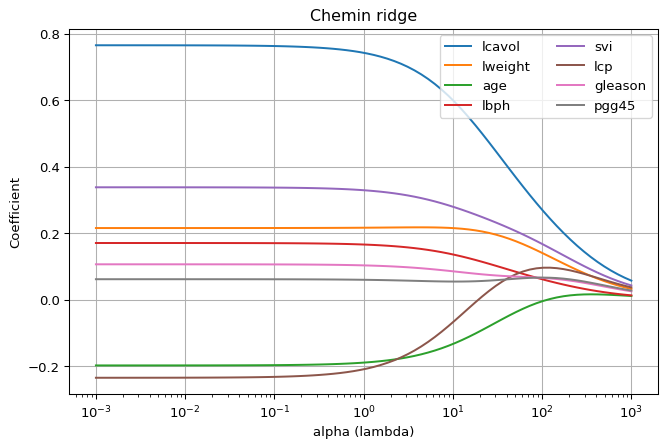

In [31]:
alphas=np.logspace(-3,3,80)
path=np.array([Ridge(alpha=a).fit(X_train_s,y_train).coef_ for a in alphas])
fig,ax=plt.subplots(figsize=(8,5))
for j,name in enumerate(feature_names): ax.plot(alphas,path[:,j],label=name)
ax.set_xscale('log');ax.set(xlabel='alpha (lambda)',ylabel='Coefficient',title='Chemin ridge');ax.legend(ncol=2);ax.grid(True);plt.show()

**Réponse.** Quand alpha augmente, les coefficients convergent progressivement vers zéro, généralement sans devenir exactement nuls.

**Q4.** Now remains the question of choosing the optimal $\lambda$. We are going to select it with a 5-fold cross-validation.

Display the evolution of the cross-validated MSE w.r.t. $\lambda$ (use again a logarithmic scale for the x-axis), and display the best $\lambda$ with a `plt.axvline`.

Now retrain the ridge regression model with the selected $\lambda$, and assess its performance in terms of MSE and MAE. Comment.

alpha retenu 1.091; MSE CV 0.5213; MSE test 0.5219; MAE test 0.5558


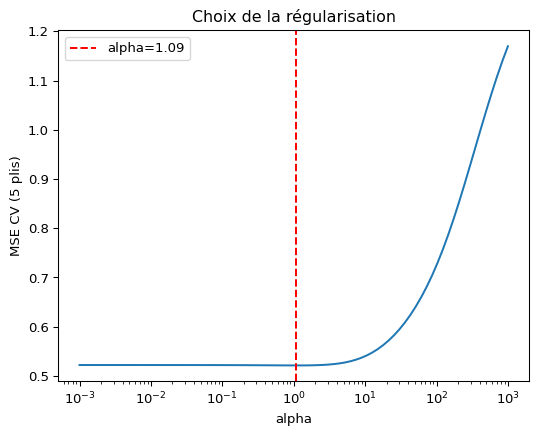

In [34]:
from sklearn.model_selection import KFold
# À chaque pli, l'échelle est ajustée sur le sous-ensemble d'entraînement.
kf=KFold(n_splits=5,shuffle=True,random_state=0)
fold_mse=[]
for alpha in alphas:
    scores=[]
    for it,iv in kf.split(X_train):
        sc=StandardScaler().fit(X_train[it])
        model=Ridge(alpha=alpha).fit(sc.transform(X_train[it]),y_train[it])
        scores.append(mean_squared_error(y_train[iv],model.predict(sc.transform(X_train[iv]))))
    fold_mse.append(np.mean(scores))
fold_mse=np.array(fold_mse);best_alpha=alphas[np.argmin(fold_mse)]
fig,ax=plt.subplots();ax.plot(alphas,fold_mse);ax.axvline(best_alpha,color='r',ls='--',label=f'alpha={best_alpha:.3g}')
ax.set_xscale('log');ax.set(xlabel='alpha',ylabel='MSE CV (5 plis)',title='Choix de la régularisation');ax.legend();plt.show()
best_ridge=Ridge(alpha=best_alpha).fit(X_train_s,y_train)
p=best_ridge.predict(X_test_s)
print(f'alpha retenu {best_alpha:.4g}; MSE CV {fold_mse.min():.4f}; MSE test {mean_squared_error(y_test,p):.4f}; MAE test {mean_absolute_error(y_test,p):.4f}')

### Part 3 (Bonus) - LASSO

Display the same kind of plots as in Part 2, but using LASSO regression instead of ridge regression (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html). In particular, comment on the following points :
* Do the regression coefficients evolve in the same way as ridge regression ? What kind of solutions do we obtain ?
* Do we get the same optimal lambda ?

alpha Lasso 0.0001, coefficients nuls 0/8, MSE test 0.5399


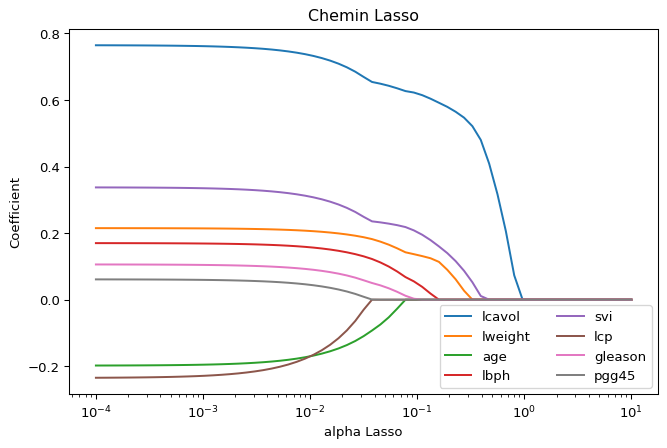

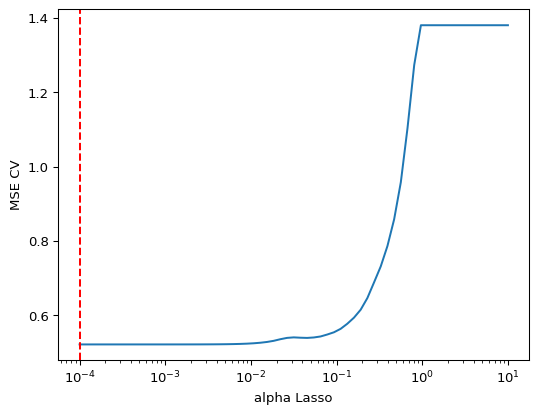

In [36]:
from sklearn.linear_model import Lasso
# Bonus : la convention de Lasso est (1/(2n))||y-Xw||² + alpha||w||₁.
lasso_alphas=np.logspace(-4,1,65)
lasso_path=np.array([Lasso(alpha=a,max_iter=20000).fit(X_train_s,y_train).coef_ for a in lasso_alphas])
fig,ax=plt.subplots(figsize=(8,5))
for j,name in enumerate(feature_names):ax.plot(lasso_alphas,lasso_path[:,j],label=name)
ax.set_xscale('log');ax.set(xlabel='alpha Lasso',ylabel='Coefficient',title='Chemin Lasso');ax.legend(ncol=2);plt.show()
cv_lasso=[]
for a in lasso_alphas:
    fold=[]
    for it,iv in kf.split(X_train):
        sc=StandardScaler().fit(X_train[it]);m=Lasso(alpha=a,max_iter=20000).fit(sc.transform(X_train[it]),y_train[it])
        fold.append(mean_squared_error(y_train[iv],m.predict(sc.transform(X_train[iv]))))
    cv_lasso.append(np.mean(fold))
a_lasso=lasso_alphas[np.argmin(cv_lasso)]
fig,ax=plt.subplots();ax.plot(lasso_alphas,cv_lasso);ax.axvline(a_lasso,color='r',ls='--');ax.set_xscale('log');ax.set(xlabel='alpha Lasso',ylabel='MSE CV');plt.show()
m=Lasso(alpha=a_lasso,max_iter=20000).fit(X_train_s,y_train)
print(f'alpha Lasso {a_lasso:.4g}, coefficients nuls {np.sum(m.coef_==0)}/8, MSE test {mean_squared_error(y_test,m.predict(X_test_s)):.4f}')

**Réponse.** Contrairement à ridge, Lasso peut annuler exactement des coefficients : il réalise une sélection de variables. Ses valeurs alpha suivent une convention de pénalisation différente ; les alpha optimaux ne sont donc pas directement comparables.